In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [1]:
%cd "/content/drive/MyDrive/drone-human-detection-and-counting-system"

/content/drive/MyDrive/drone-human-detection-and-counting-system


In [2]:
import os
ROOT_DIR = os.getcwd()
print(f'Root directory: {ROOT_DIR}')

Root directory: /content/drive/MyDrive/drone-human-detection-and-counting-system


****
# Imports

In [3]:
import os
import cv2
import yaml
import math
import torch
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from pathlib import Path
from ultralytics import YOLO
from collections import defaultdict

warnings.filterwarnings("ignore")

In [4]:
# load yaml training config file
with open(Path(ROOT_DIR, 'configs/train_config.yaml'), 'r') as f:
    cfg = yaml.safe_load(f)

*****
# Training

In [5]:
device = torch.device(0 if torch.cuda.is_available() else 'cpu')
print(f"Device name: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")

Device name: NVIDIA A100-SXM4-80GB


In [6]:
model = YOLO(cfg['model'])

In [7]:
TRAIN_KEYS = [
    "task", "imgsz", "batch", "epochs", "patience", "save_period",
    "optimizer", "lr0", "lrf", "cos_lr", "cls", "angle",
    "close_mosaic", "scale", "translate", "hsv_h", "hsv_s", "hsv_v", "erasing",
    "multi_scale", "max_det", "conf", "cache", "workers", "name", "exist_ok",
]
train_kwargs = {k: cfg[k] for k in TRAIN_KEYS if k in cfg}

In [8]:
results = model.train(data=cfg["data"], **train_kwargs)

New https://pypi.org/project/ultralytics/8.4.51 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.50 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-80GB, 81153MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=45.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=disk, cfg=None, classes=None, close_mosaic=20, cls=1.0, cls_pw=0.0, compile=False, conf=0.15, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=./configs/ds_config.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=80, erasing=0.2, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.5, hsv_v=0.3, imgsz=720, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=1000, mixup=0.0, mode=train, model=yolo26l-obb.pt, momentum=0.937, mosaic=1.0, multi_scale

*****
# Quick Inference

In [51]:
RUNS_OBB = Path(ROOT_DIR, "runs", "obb")
RUN_DIR = Path(RUNS_OBB, RUN_NAME)
RESULTS_DIR = Path(RUNS_OBB, "results")
MODEL_PATH = Path(RUN_DIR, "weights", "best.pt")
os.makedirs(RESULTS_DIR, exist_ok=True)

IMGSZ = cfg["imgsz"]
CONF_THRESH = cfg.get("conf", 0.15)
IOU_THRESH = cfg.get("iou", 0.6)
CLASS_NAMES = {0: "human", 1: "car"}
CLASS_COLORS = {0: (220, 50, 50), 1: (50, 220, 50)}
OUTPUT_DIR = Path(ROOT_DIR, "output")
os.makedirs(OUTPUT_DIR, exist_ok=True)

with open(Path(ROOT_DIR, cfg["data"]), "r", encoding="utf-8") as f:
    ds_cfg = yaml.safe_load(f)
print(f"Run: {RUN_DIR}")

Run: /content/drive/MyDrive/drone-human-detection-and-counting-system/runs/obb/yolo26l_drone_v2


In [13]:
# load best model
model = YOLO(MODEL_PATH)

In [14]:
def draw_obb_results(result, class_names, class_colors, conf_thresh=0.25):
    """Draw OBB polygons + labels onto the image. Returns RGB numpy array."""
    img = result.orig_img.copy()                          # BGR
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    if result.obb is None or len(result.obb) == 0:
        return img

    boxes  = result.obb.xyxyxyxy.cpu().numpy()            # (N, 4, 2) pixel coords
    confs  = result.obb.conf.cpu().numpy()
    clsids = result.obb.cls.cpu().numpy().astype(int)

    for pts, conf, cls_id in zip(boxes, confs, clsids):
        if conf < conf_thresh:
            continue
        color   = class_colors.get(cls_id, (200, 200, 200))
        pts_int = pts.astype(np.int32)
        cv2.polylines(img, [pts_int], isClosed=True, color=color, thickness=2)
        label = f"{class_names[cls_id]} {conf:.2f}"
        x0, y0 = pts_int[0]
        cv2.putText(img, label, (x0, max(y0 - 6, 0)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.55, color, 2, cv2.LINE_AA)
    return img

WARNING ⚠️ imgsz=[720] must be multiple of max stride 32, updating to [736]


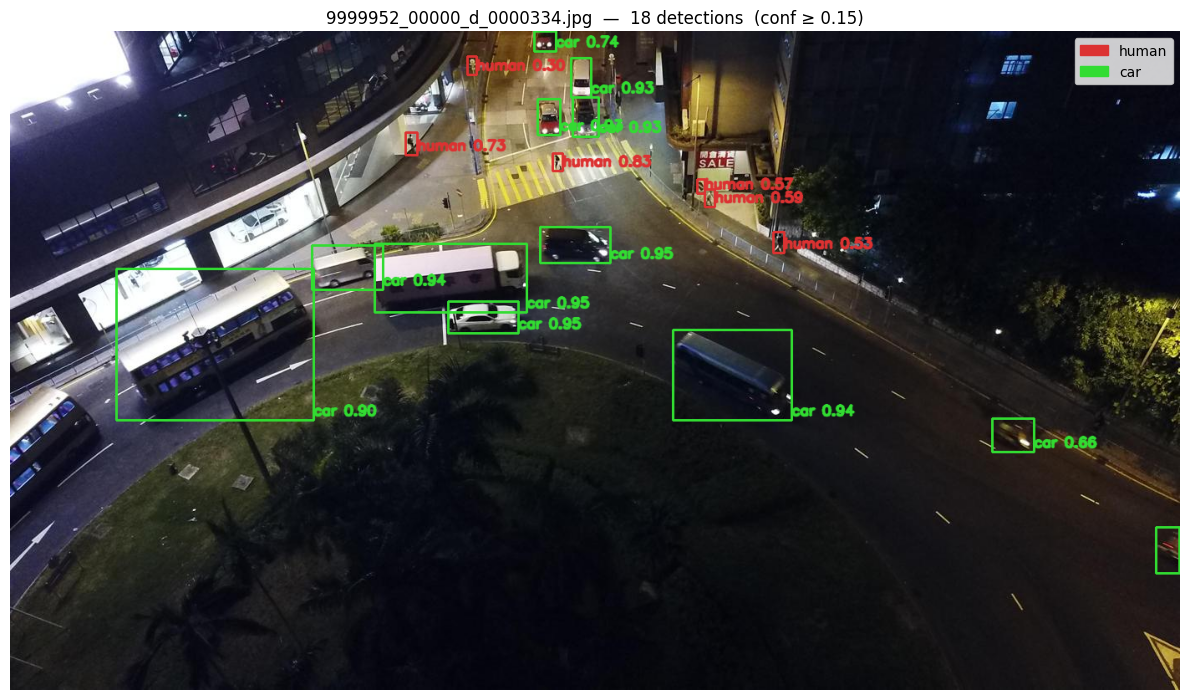

Image         : 9999952_00000_d_0000334.jpg
Detections    : 18
Classes found : ['car', 'car', 'car', 'car', 'car', 'car', 'car', 'car', 'car', 'human', 'car', 'human', 'car', 'human', 'human', 'human', 'car', 'human']
Confidences   : [      0.953       0.949       0.946        0.94       0.935       0.932        0.93       0.925       0.904       0.826       0.742       0.726       0.656       0.592       0.573       0.535       0.459       0.304]


In [21]:
test_img_dir = Path(ds_cfg['path']) / ds_cfg['test']
test_images  = list(test_img_dir.glob('*.jpg')) + list(test_img_dir.glob('*.png'))
sample_img   = random.choice(test_images)

result = model.predict(
    source  = str(sample_img),
    imgsz   = IMGSZ,
    conf    = CONF_THRESH,
    iou     = IOU_THRESH,
    device  = device,
    verbose = False,
)[0]

annotated = draw_obb_results(result, CLASS_NAMES, CLASS_COLORS, CONF_THRESH)
n_det = len(result.obb) if result.obb is not None else 0

plt.figure(figsize=(12, 8))
plt.imshow(annotated)
plt.title(f'{sample_img.name}  —  {n_det} detections  (conf ≥ {CONF_THRESH})', fontsize=12)
plt.axis('off')

# legend
legend = [mpatches.Patch(color=np.array(c)/255, label=CLASS_NAMES[i]) for i, c in CLASS_COLORS.items()]
plt.legend(handles=legend, loc='upper right', fontsize=10)
plt.tight_layout()
plt.savefig(Path(OUTPUT_DIR ,'single_image_inference.png'), dpi=150, bbox_inches='tight')
plt.show()

# raw OBB tensor info
print(f'Image         : {sample_img.name}')
print(f'Detections    : {n_det}')
if n_det > 0:
    print(f'Classes found : {[CLASS_NAMES[c] for c in result.obb.cls.cpu().numpy().astype(int)]}')
    print(f'Confidences   : {result.obb.conf.cpu().numpy().round(3)}')

*****
# Training & Validation Curves

### Validation Data

In [41]:
print("Evaluate Best model on Validation split...")

val_metrics = model.val(
    data    = cfg['data'],
    split   = 'val',
    task    = cfg['task'],
    imgsz   = cfg['imgsz'],
    conf    = CONF_THRESH,      # sweep full PR curve
    iou     = IOU_THRESH,
    device  = device,
    plots   = True,
    name    = 'val_eval',
    verbose = True,
)

print("VALIDATION RESULTS")
print(f"mAP@0.5          : {val_metrics.box.map50:.4f}")
print(f"mAP@0.5:0.95     : {val_metrics.box.map:.4f}")
print(f"Mean Precision   : {val_metrics.box.mp:.4f}")
print(f"Mean Recall      : {val_metrics.box.mr:.4f}")

# Per-class AP
print("\n  Per-class AP@0.5:")
for cls_id, cls_name in CLASS_NAMES.items():
    if cls_id < len(val_metrics.box.ap50):
        ap = val_metrics.box.ap50[cls_id]
        print(f"    [{cls_id}] {cls_name:8s}: {ap:.4f}")

Evaluate Best model on Validation split...
WARNING ⚠️ imgsz=[720] must be multiple of max stride 32, updating to [736]
val: Fast image access ✅ (ping: 0.3±0.1 ms, read: 95.9±62.6 MB/s, size: 178.1 KB)
val: Scanning /content/drive/MyDrive/drone-human-detection-and-counting-system/dataset/VisDrone_Dataset/VisDrone2019-DET-val/labels.cache... 548 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 548/548 153.2Mit/s 0.0s
val: /content/drive/MyDrive/drone-human-detection-and-counting-system/dataset/VisDrone_Dataset/VisDrone2019-DET-val/images/0000271_01201_d_0000379.jpg: 1 duplicate labels removed
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 35/35 2.2it/s 15.7s
                   all        548      38758      0.797      0.694      0.725      0.528
                 human        531      13969      0.779      0.598      0.635      0.406
                   car        546      24789      0.816       0.79      0.814      0.649
Spee

[('confusion_matrix.png', 'Confusion Matrix'), ('confusion_matrix_normalized.png', 'Confusion Matrix (Normalised)')]


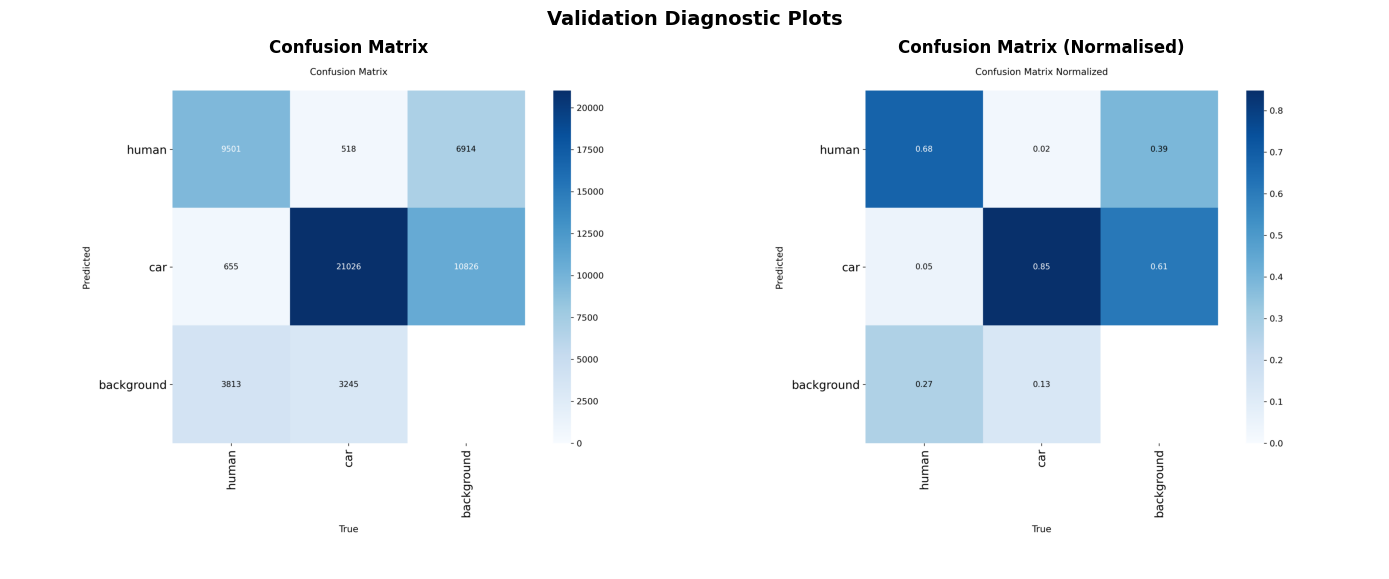

In [45]:
val_eval_dir = Path(RUNS_OBB, 'val_eval')

diagnostic_plots = [
    ('confusion_matrix.png',       'Confusion Matrix'),
    ('confusion_matrix_normalized.png', 'Confusion Matrix (Normalised)'),
    ('PR_curve.png',               'Precision–Recall Curve'),
    ('F1_curve.png',               'F1 Score Curve'),
    ('P_curve.png',                'Precision Curve'),
    ('R_curve.png',                'Recall Curve'),
]

available = [(name, title) for name, title in diagnostic_plots if (val_eval_dir / name).exists()]
print(available)
n = len(available)
cols = min(n, 3)
rows = math.ceil(n / cols)
fig, axes = plt.subplots(rows, cols, figsize=(7 * cols, 6 * rows))
axes = np.array(axes).flatten()   # always 1-D for easy indexing

for ax, (fname, title) in zip(axes, available):
    img = plt.imread(str(val_eval_dir / fname))   # load PNG as float array
    ax.imshow(img)
    ax.set_title(title, fontweight='bold')
    ax.axis('off')

# Hide unused axes
for ax in axes[len(available):]:
    ax.set_visible(False)

fig.suptitle('Validation Diagnostic Plots', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(Path(val_eval_dir,'val_results.png'), dpi=130, bbox_inches='tight')
plt.show()

### Test Data

In [46]:
print("Evaluate model on Test split...")

test_metrics = model.val(
    data    = cfg['data'],
    split   = 'test',
    task    = cfg['task'],
    imgsz   = cfg['imgsz'],
    conf    = CONF_THRESH,      # sweep full PR curve
    iou     = IOU_THRESH,
    device  = device,
    plots   = True,
    name    = 'test_eval',
    verbose = True,
)

print("TEST RESULTS")
print(f"mAP@0.5          : {test_metrics.box.map50:.4f}")
print(f"mAP@0.5:0.95     : {test_metrics.box.map:.4f}")
print(f"Mean Precision   : {test_metrics.box.mp:.4f}")
print(f"Mean Recall      : {test_metrics.box.mr:.4f}")

# Per-class AP
print("\n  Per-class AP@0.5:")
for cls_id, cls_name in CLASS_NAMES.items():
    if cls_id < len(test_metrics.box.ap50):
        ap = test_metrics.box.ap50[cls_id]
        print(f"    [{cls_id}] {cls_name:8s}: {ap:.4f}")

Evaluate model on Test split...
WARNING ⚠️ imgsz=[720] must be multiple of max stride 32, updating to [736]
val: Fast image access ✅ (ping: 0.4±0.1 ms, read: 0.3±0.1 MB/s, size: 170.5 KB)
val: Scanning /content/drive/MyDrive/drone-human-detection-and-counting-system/dataset/VisDrone_Dataset/VisDrone2019-DET-test-dev/labels... 1610 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1610/1610 8.5it/s 3:10
val: New cache created: /content/drive/MyDrive/drone-human-detection-and-counting-system/dataset/VisDrone_Dataset/VisDrone2019-DET-test-dev/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 101/101 4.2it/s 24.2s
                   all       1610      75102      0.775      0.617      0.629      0.442
                 human       1267      27382       0.72      0.457      0.472      0.268
                   car       1588      47720      0.831      0.777      0.786      0.616
Speed: 0.6ms preprocess, 2.9ms inference, 

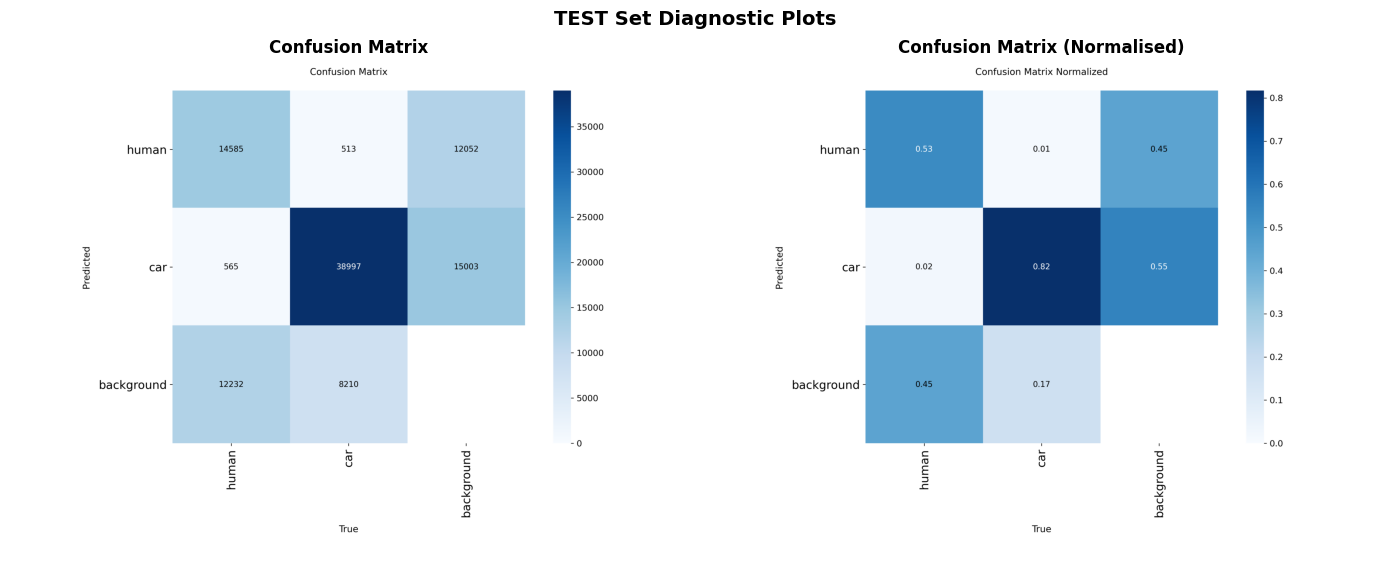

In [47]:
test_eval_dir = Path(RUNS_OBB, 'test_eval')

available_test = [(name, title) for name, title in diagnostic_plots if (test_eval_dir / name).exists()]
n = len(available_test)
cols = min(n, 3)
rows = math.ceil(n / cols)
fig, axes = plt.subplots(rows, cols, figsize=(7 * cols, 6 * rows))
axes = np.array(axes).flatten()

for ax, (fname, title) in zip(axes, available_test):
    img = plt.imread(str(test_eval_dir / fname))
    ax.imshow(img)
    ax.set_title(title, fontweight='bold')
    ax.axis('off')

for ax in axes[len(available_test):]:
    ax.set_visible(False)

fig.suptitle('TEST Set Diagnostic Plots', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(Path(test_eval_dir, 'test_results.png'), dpi=130, bbox_inches='tight')
plt.show()

Sweeping confidence thresholds on test split ...
    GT persons : 27,382
    GT cars    : 47,720
    GT total   : 75,102
    Running base inference at conf=0.01 (once, then filter) ...
WARNING ⚠️ imgsz=[720] must be multiple of max stride 32, updating to [736]
    Cached predictions for 1610 images.

    Best F1 = 0.9512  at conf = 0.20
      Precision = 0.9608
      Recall    = 0.9418


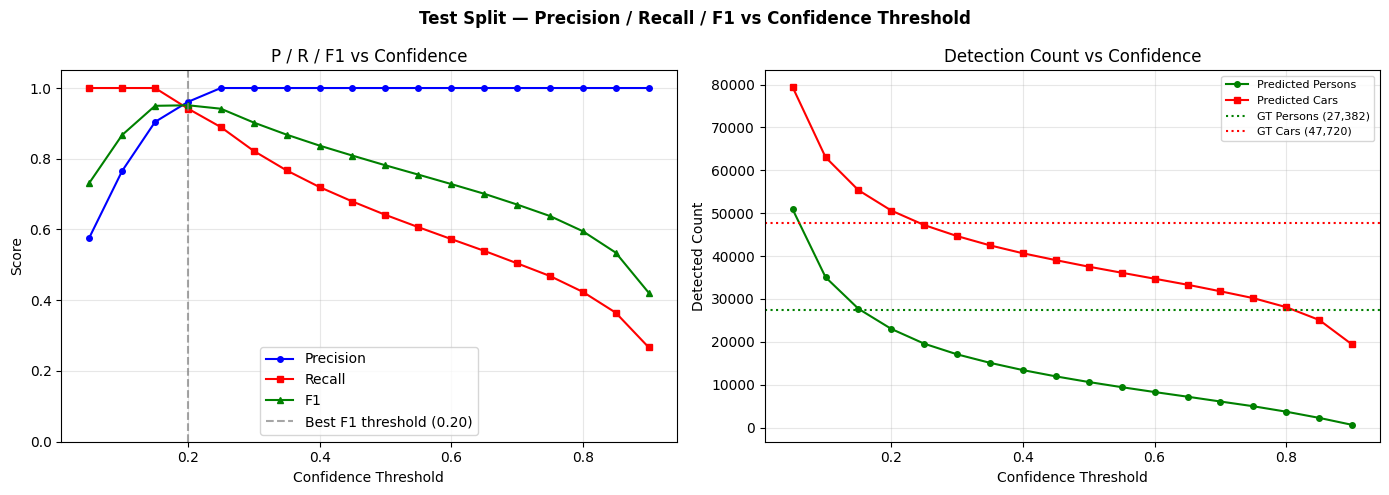

In [52]:
print("Sweeping confidence thresholds on test split ...")

# Collect ground-truth counts from test labels
test_lbl_dir = Path(ds_cfg['path'], 'VisDrone2019-DET-test-dev/labels')
test_img_dir = Path(ds_cfg['path'], ds_cfg['test'])
test_img_paths = sorted(test_img_dir.glob('*.jpg'))

# Count GT objects per class across the entire test split
gt_counts = defaultdict(int)
for lbl_path in test_lbl_dir.glob('*.txt'):
    with open(lbl_path) as f:
        for line in f:
            if line.strip():
                cls_id = int(line.split()[0])
                gt_counts[cls_id] += 1

total_gt = sum(gt_counts.values())
print(f"    GT persons : {gt_counts[0]:,}")
print(f"    GT cars    : {gt_counts[1]:,}")
print(f"    GT total   : {total_gt:,}")

# ── Threshold sweep ────────────────────────────────────────────────────────────
# We run predict() on all test images once per threshold.
# To avoid loading images repeatedly, we cache predictions at conf=0.01
# and then filter by threshold at each step (faster).

SWEEP_CONFS = np.linspace(0.05, 0.90, 18)   # 18 confidence values to test

# Run inference at very low conf to get raw predictions we can filter later
print("    Running base inference at conf=0.01 (once, then filter) ...")
raw_preds = model.predict(
    source  = str(test_img_dir),
    task    = 'obb',
    imgsz   = cfg['imgsz'],
    conf    = 0.01,    # very low: keep almost everything for filtering
    iou     = 0.45,
    device  = device,
    verbose = False,
    stream  = True,    # generator to avoid loading all results into RAM
)

# Cache raw detections as (img_stem → list of (conf, cls_id))
cached_dets = {}   # {stem: [(conf_score, class_id), ...]}
for result in raw_preds:
    stem = Path(result.path).stem
    dets = []
    if result.obb is not None and len(result.obb):
        confs = result.obb.conf.cpu().numpy()   # confidence scores
        clses = result.obb.cls.cpu().numpy().astype(int)  # class ids
        dets  = list(zip(confs, clses))
    cached_dets[stem] = dets

print(f"    Cached predictions for {len(cached_dets)} images.\n")

# ── Filter and compute P/R/F1 at each threshold ───────────────────────────────
sweep_rows = []

for conf_t in SWEEP_CONFS:
    # For each threshold, count TP by comparing detected classes to GT
    # Simple counting-based approximation (not IoU-matched AP)
    pred_counts  = defaultdict(int)

    for stem, dets in cached_dets.items():
        for (c, cls_id) in dets:
            if c >= conf_t:
                pred_counts[cls_id] += 1

    total_pred = sum(pred_counts.values())

    # Simple precision/recall approximation
    # True positives ≈ min(predicted, ground-truth) per class
    tp_person = min(pred_counts[0], gt_counts[0])
    tp_car    = min(pred_counts[1], gt_counts[1])
    tp_total  = tp_person + tp_car

    precision = tp_total / total_pred if total_pred > 0 else 0.0
    recall    = tp_total / total_gt   if total_gt   > 0 else 0.0
    f1        = (2 * precision * recall / (precision + recall)
                 if (precision + recall) > 0 else 0.0)

    sweep_rows.append(dict(
        conf=conf_t,
        precision=precision,
        recall=recall,
        f1=f1,
        total_pred=total_pred,
        pred_person=pred_counts[0],
        pred_car=pred_counts[1],
    ))

sweep_df = pd.DataFrame(sweep_rows)

# Find best F1 threshold
best_f1_row = sweep_df.loc[sweep_df['f1'].idxmax()]
print(f"    Best F1 = {best_f1_row['f1']:.4f}  at conf = {best_f1_row['conf']:.2f}")
print(f"      Precision = {best_f1_row['precision']:.4f}")
print(f"      Recall    = {best_f1_row['recall']:.4f}")

# ── Plot sweep results ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Test Split — Precision / Recall / F1 vs Confidence Threshold',
             fontsize=12, fontweight='bold')

# P/R/F1 vs threshold
ax = axes[0]
ax.plot(sweep_df['conf'], sweep_df['precision'], 'b-o', ms=4, label='Precision')
ax.plot(sweep_df['conf'], sweep_df['recall'],    'r-s', ms=4, label='Recall')
ax.plot(sweep_df['conf'], sweep_df['f1'],        'g-^', ms=4, label='F1')
ax.axvline(best_f1_row['conf'], color='gray', linestyle='--', alpha=0.7,
           label=f"Best F1 threshold ({best_f1_row['conf']:.2f})")
ax.set_xlabel('Confidence Threshold')
ax.set_ylabel('Score')
ax.set_title('P / R / F1 vs Confidence')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 1.05)

# Predicted count vs threshold
ax = axes[1]
ax.plot(sweep_df['conf'], sweep_df['pred_person'], 'g-o', ms=4, label='Predicted Persons')
ax.plot(sweep_df['conf'], sweep_df['pred_car'],    'r-s', ms=4, label='Predicted Cars')
ax.axhline(gt_counts[0], color='green', linestyle=':', lw=1.5, label=f'GT Persons ({gt_counts[0]:,})')
ax.axhline(gt_counts[1], color='red',   linestyle=':', lw=1.5, label=f'GT Cars ({gt_counts[1]:,})')
ax.set_xlabel('Confidence Threshold')
ax.set_ylabel('Detected Count')
ax.set_title('Detection Count vs Confidence')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
sweep_path = Path(RESULTS_DIR, 'test_threshold_sweep.png')
plt.savefig(sweep_path, dpi=150, bbox_inches='tight')
plt.show()

# Save sweep table
sweep_csv = Path(RESULTS_DIR, 'test_threshold_sweep.csv')
sweep_df.round(4).to_csv(sweep_csv, index=False)


════════════════════════════════════════════════════════════
  VALIDATION  vs  TEST — YOLO26l-OBB on VisDrone
════════════════════════════════════════════════════════════
            mAP@0.5  mAP@0.5:0.95  Precision  Recall  AP@0.5 person  AP@0.5 car
Split                                                                          
Validation   0.7246        0.5275     0.7973  0.6935         0.6347      0.8144
Test         0.6288        0.4419     0.7750  0.6173         0.4720      0.7856
════════════════════════════════════════════════════════════

Metrics table saved → /content/drive/MyDrive/drone-human-detection-and-counting-system/runs/obb/results/val_vs_test_metrics.csv


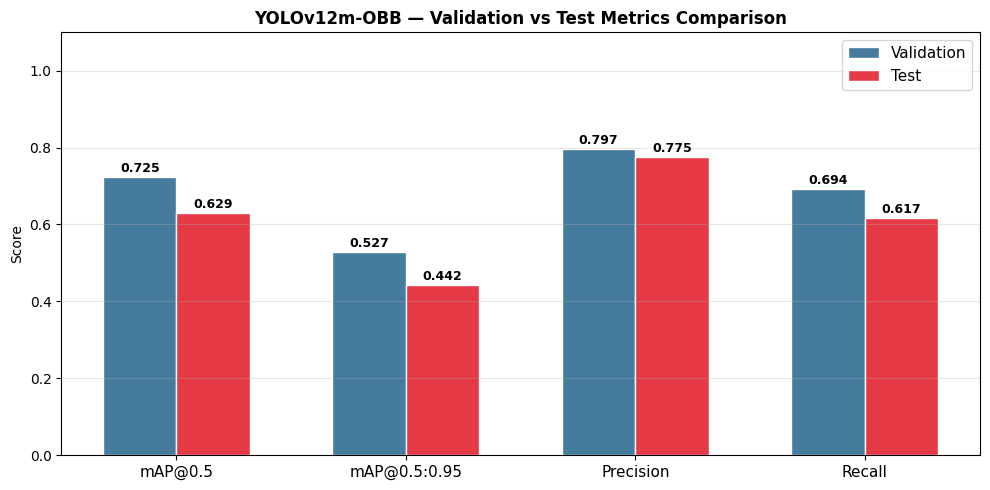

In [53]:
def extract_metrics(metrics_obj, label):
    """Pull standard fields from an ultralytics DetMetrics object."""
    row = {'Split': label}
    try:
        row['mAP@0.5']       = round(metrics_obj.box.map50, 4)
        row['mAP@0.5:0.95']  = round(metrics_obj.box.map,   4)
        row['Precision']      = round(metrics_obj.box.mp,    4)
        row['Recall']         = round(metrics_obj.box.mr,    4)
        row['AP@0.5 person']  = round(metrics_obj.box.ap50[0], 4) if len(metrics_obj.box.ap50) > 0 else None
        row['AP@0.5 car']     = round(metrics_obj.box.ap50[1], 4) if len(metrics_obj.box.ap50) > 1 else None
    except Exception as e:
        print(f"Could not extract all metrics for {label}: {e}")
    return row

rows = [
    extract_metrics(val_metrics,  'Validation'),
    extract_metrics(test_metrics, 'Test'),
]

cmp_df = pd.DataFrame(rows).set_index('Split')

print("\n" + "═" * 60)
print("  VALIDATION  vs  TEST — YOLO26l-OBB on VisDrone")
print("═" * 60)
print(cmp_df.to_string())
print("═" * 60)

# Save as CSV for the report
cmp_csv = Path(RESULTS_DIR, 'val_vs_test_metrics.csv')
cmp_df.to_csv(cmp_csv)
print(f"\nMetrics table saved → {cmp_csv}")

# ── Visual comparison bar chart ───────────────────────────────────────────────
metrics_to_plot = ['mAP@0.5', 'mAP@0.5:0.95', 'Precision', 'Recall']
x     = np.arange(len(metrics_to_plot))
width = 0.32

fig, ax = plt.subplots(figsize=(10, 5))
bars_val  = ax.bar(x - width/2, [cmp_df.loc['Validation', m] for m in metrics_to_plot], width, label='Validation', color='#457b9d', edgecolor='white')
bars_test = ax.bar(x + width/2, [cmp_df.loc['Test',       m] for m in metrics_to_plot], width, label='Test',       color='#e63946', edgecolor='white')

# Annotate bars with values
for bar in list(bars_val) + list(bars_test):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.005,
            f'{h:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(metrics_to_plot, fontsize=11)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.set_title('YOLOv12m-OBB — Validation vs Test Metrics Comparison',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
cmp_plot_path = Path(RESULTS_DIR,'val_vs_test_comparison.png')
plt.savefig(cmp_plot_path, dpi=150, bbox_inches='tight')
plt.show()

*****
# OBB ppprediction on 4 random test images

WARNING ⚠️ imgsz=[720] must be multiple of max stride 32, updating to [736]


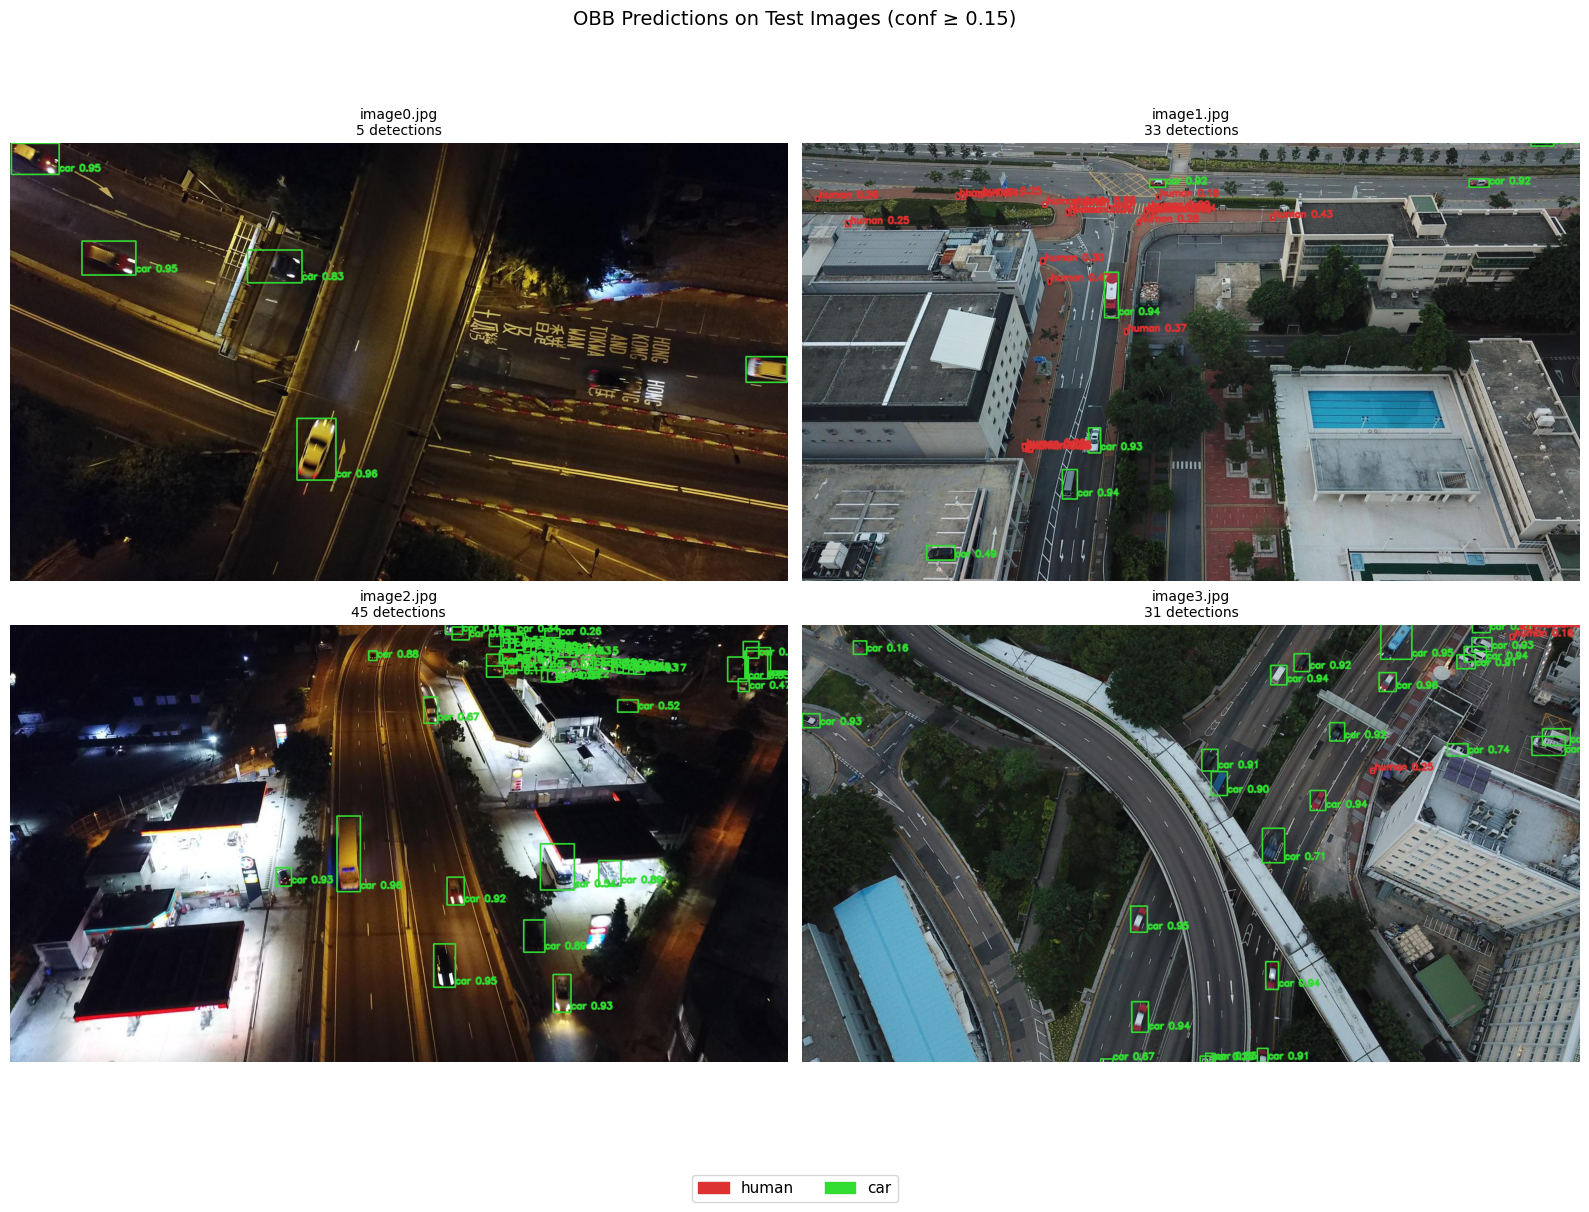

In [62]:
sample_imgs = random.sample(test_images, min(4, len(test_images)))

results = model.predict(
    source  = [str(p) for p in sample_imgs],
    imgsz   = cfg['imgsz'],
    conf    = CONF_THRESH,
    iou     = IOU_THRESH,
    device  = device,
    verbose = False,
)

# ---- Dynamic layout ----
n = len(results)
cols = min(2, n)              # max 2 columns
rows = int(np.ceil(n / cols))
fig, axes = plt.subplots(rows, cols, figsize=(8 * cols, 6 * rows))

# Handle single-image case
if n == 1:
    axes = [axes]
else:
    axes = axes.flatten()

for ax, res in zip(axes, results):
    annotated = draw_obb_results(res, CLASS_NAMES, CLASS_COLORS, CONF_THRESH)
    n_det = len(res.obb) if res.obb is not None else 0
    ax.imshow(annotated)
    ax.set_title(f'{Path(res.path).name}\n{n_det} detections', fontsize=10)
    ax.axis('off')

# Hide unused axes
for ax in axes[len(results):]:
    ax.set_visible(False)
legend = [mpatches.Patch(color=np.array(c) / 255, label=CLASS_NAMES[i]) for i, c in CLASS_COLORS.items()]

fig.legend(handles=legend, loc='lower center', ncol=2, fontsize=11, bbox_to_anchor=(0.5, -0.02))
plt.suptitle(f'OBB Predictions on Test Images (conf ≥ {CONF_THRESH})', fontsize=14)
plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.savefig(Path(RESULTS_DIR, 'qualitative_test_predictions.png'), dpi=120, bbox_inches='tight')
plt.show()